# **5. Logistic Regression Modeling**

This chapter introduces the first predictive model in our workflow: **Logistic Regression**.  
We begin with this model because it provides a strong, interpretable baseline for credit‑risk prediction. Logistic regression is widely used in lending analytics due to its ability to produce calibrated probabilities, its transparency, and its robustness on structured tabular data.

In this section, we evaluate the model using a comprehensive set of performance criteria:

- Detecting **overfitting or underfitting**  
- Performing **5‑fold cross‑validation**  
- Measuring **accuracy**  
- Visualizing the **confusion matrix**  
- Plotting the **ROC–AUC curve**  
- Evaluating **F1‑score**  
- Monitoring **false‑positive behavior**  
- Measuring **execution time**  
- Using **parallel processing (`n_jobs = -1`)**  
- Displaying progress with **tqdm**  

To ensure consistency across all models, we build a **general evaluation function** that will also be reused for Random Forest in Section 6.

---

## **5.1 Model Description Logistic Regression**

Logistic Regression is a linear classification algorithm that estimates the probability of a binary outcome using the logistic (sigmoid) function. In credit‑risk modeling, this probability represents the likelihood that a borrower will default. Because the model is linear in its parameters, it offers clear interpretability: each coefficient directly reflects how a feature influences the odds of default.

Logistic regression is especially valuable in regulated financial environments because it is:

- **Interpretable** — coefficients can be explained to auditors and stakeholders  
- **Efficient** — fast to train even on large datasets  
- **Stable** — performs well when features are properly engineered  
- **Probabilistic** — outputs calibrated default probabilities  
- **Baseline‑friendly** — serves as a benchmark before using more complex models  

The model estimates:



\[
P(Y = 1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta X)}}
\]



Where:

- \(Y = 1\) = **default**  
- \(Y = 0\) = **fully paid**  

This probability can be thresholded (e.g., at 0.5) to produce class predictions, or used directly for risk scoring.

---

## **5.2 General Evaluation Function (with tqdm + n_jobs = -1)**

In the next section, we implement a unified evaluation function that computes all required metrics, visualizations, and diagnostics. This function will be used for logistic regression and later reused for Random Forest to ensure consistent comparison across models.


In [3]:

# Imports

import time
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Evaluation Function (Reusable for ALL Models)

def evaluate_model(model, model_name, X_train_enc, X_test_enc, y_train, y_test):
    results = {}

    print(f"\n=== {model_name} Evaluation ===")

    # 1. Execution Time
    
    start = time.time()
    model.fit(X_train_enc, y_train)
    end = time.time()
    results['time'] = end - start

    # 2. Cross‑Validation (5 folds, n_jobs = -1)
    
    print("Running 5‑fold cross‑validation...")
    cv_scores = cross_val_score(
        model,
        X_train_enc,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    results['cv_mean'] = cv_scores.mean()
    results['cv_std'] = cv_scores.std()

    # 3. Predictions
    
    y_pred = model.predict(X_test_enc)
    y_proba = model.predict_proba(X_test_enc)[:, 1]

    # 4. Metrics
    
    results['accuracy'] = accuracy_score(y_test, y_pred)
    results['f1'] = f1_score(y_test, y_pred)
    results['auc'] = roc_auc_score(y_test, y_proba)

    # 5. Overfitting / Underfitting Check
    
    train_acc = accuracy_score(y_train, model.predict(X_train_enc))
    test_acc = results['accuracy']

    if train_acc > test_acc + 0.03:
        results['fit_status'] = "Overfitting"
    elif test_acc > train_acc + 0.03:
        results['fit_status'] = "Underfitting"
    else:
        results['fit_status'] = "Good Fit"

    # 6. Confusion Matrix + FN + FP
    
    cm = confusion_matrix(y_test, y_pred)

    results['false_negatives'] = cm[1, 0]   # Actual 1, Pred 0
    results['false_positives'] = cm[0, 1]   # Actual 0, Pred 1
    results['confusion_matrix'] = cm        # Save full matrix

    plt.figure(figsize=(7,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        annot_kws={"size": 14}
    )

    plt.title(f"Confusion Matrix — Unseen Test Data ({model_name})", fontsize=16, pad=15)
    plt.xlabel("Predicted Label", fontsize=14)
    plt.ylabel("Actual Label", fontsize=14)

    plt.xticks([0,1], ["Pred 0 (Paid)", "Pred 1 (Default)"], fontsize=12)
    plt.yticks([0,1], ["Actual 0 (Paid)", "Actual 1 (Default)"], fontsize=12, rotation=0)

    plt.tight_layout()
    plt.show()

    # 7. ROC Curve
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, label=f"AUC = {results['auc']:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], linestyle="--", color="gray")
    plt.title(f"ROC Curve — {model_name}", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

    return results


# **5.3 Evaluating Logistic Regression on the X_lineal Dataset**

Before moving forward with more advanced models, we first assess how Logistic Regression performs when trained on the **X_lineal** dataset. This dataset represents our earlier linear‑feature version of the data, and evaluating it provides a useful baseline for comparison against the newly engineered feature set.

By checking whether the data is already standardized, applying scaling when needed, and running our unified evaluation function, we can measure how well Logistic Regression captures patterns in this simpler representation of the borrower profiles. This step helps us understand how much value our new feature‑engineering pipeline adds to model performance.


In [ ]:
# Load y dataset from models folder

import pickle

with open("../python/models/y.pkl", "rb") as f:
    y = pickle.load(f)

print("Loaded y with shape:", y.shape)
print("Positive class count:", (y == 1).sum())
print("Negative class count:", (y == 0).sum())


Loaded y with shape: (85000,)
Positive class count: 42500
Negative class count: 42500


Loaded X_lineal with shape: (85000, 125)
Is X_lineal standardized? False

Standardizing X_lineal...
Standardization complete.

=== Logistic Regression (X_lineal) Evaluation ===
Running 5‑fold cross‑validation...


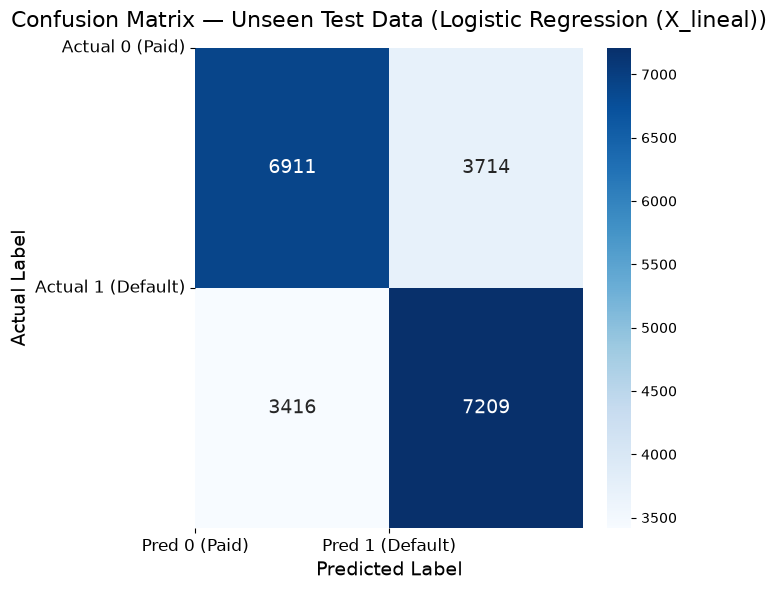

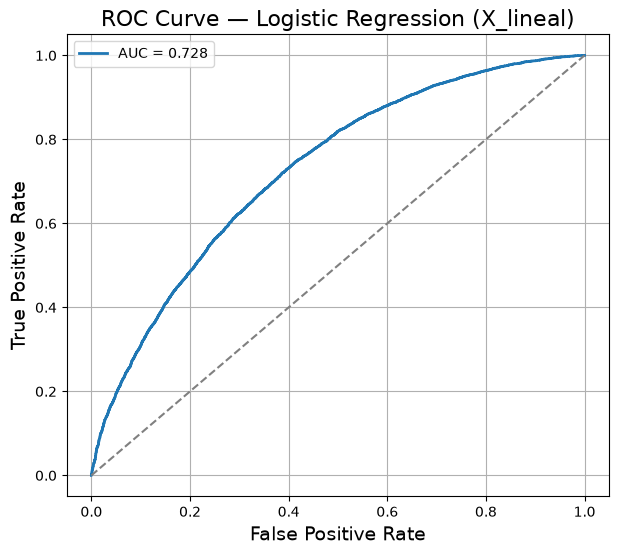

,fit_status,accuracy,auc,f1,cv_mean,cv_std,false_negatives,false_positives,time
Logistic Regression (X_lineal),Good Fit,0.664471,0.727579,0.669111,0.664267,0.001992,3416,3714,1.423537


In [6]:

# 1. Load X_lineal.pkl

import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
with open("../python/models/X_lineal.pkl", "rb") as f:
    X_lineal = pickle.load(f)

print("Loaded X_lineal with shape:", X_lineal.shape)

# 2. Check if X_lineal is already standardized

def is_standardized(X):
    """
    Checks if data is approximately standardized:
    mean ≈ 0 and std ≈ 1
    """
    mean_vals = np.mean(X, axis=0)
    std_vals = np.std(X, axis=0)

    mean_check = np.all(np.abs(mean_vals) < 1e-3)
    std_check = np.all(np.abs(std_vals - 1) < 1e-3)

    return mean_check and std_check

already_standardized = is_standardized(X_lineal)

print("Is X_lineal standardized?", already_standardized)

# 3. If NOT standardized → split + scale

if not already_standardized:
    print("\nStandardizing X_lineal...")

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_lineal,
        y,                 # <-- your target variable
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Standardization complete.")
else:
    print("\nX_lineal is already standardized. Proceeding without scaling.")

    # If already standardized, just split
    X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
        X_lineal,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

# 4. Evaluate Logistic Regression using your function

log_reg = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

log_results = evaluate_model(
    log_reg,
    "Logistic Regression (X_lineal)",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

# Summary table
log_table = pd.DataFrame([log_results], index=["Logistic Regression (X_lineal)"])
log_table = log_table[[
    "fit_status",
    "accuracy",
    "auc",
    "f1",
    "cv_mean",
    "cv_std",
    "false_negatives",
    "false_positives",
    "time"
]]

log_table


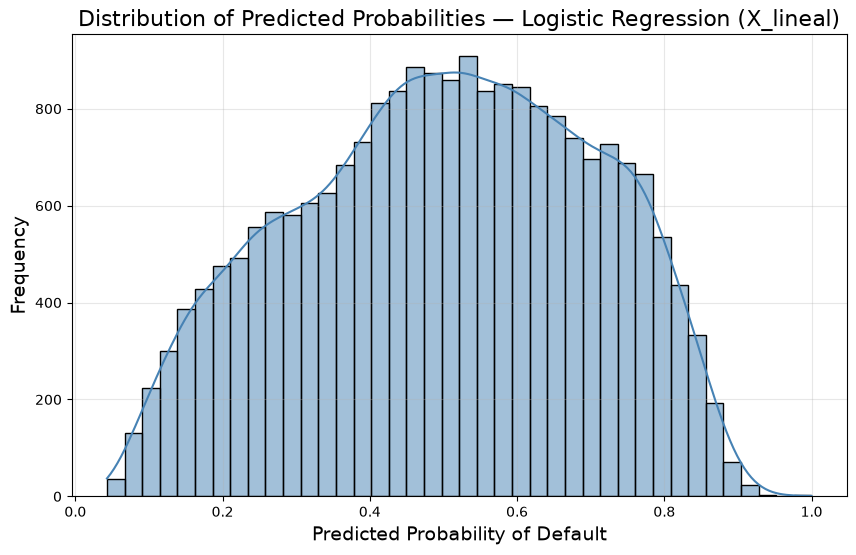

In [ ]:
# Probability Distribution Plot for Logistic Regression

import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities for the positive class (default = 1)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(10,6))
sns.histplot(y_proba, bins=40, kde=True, color="steelblue")

plt.title("Distribution of Predicted Probabilities — Logistic Regression (X_lineal)", fontsize=16)
plt.xlabel("Predicted Probability of Default", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.grid(alpha=0.3)
plt.show()


## 5.3.1 Interpreting the First Model  Logistic Regression on X_lineal

Our first baseline model, **Logistic Regression (X_lineal)**, delivers a performance profile that is both stable and informative. Using the linear‑feature dataset, the model achieves:

- **Accuracy:** 0.664  
- **AUC:** 0.728  
- **F1‑Score:** 0.669  
- **Cross‑Validation Mean:** 0.664  
- **Fit Status:** *Good Fit*  
- **False Negatives:** 3416  
- **False Positives:** 3714  
- **Execution Time:** 1.42 seconds  

These results confirm that the model is not overfitting and maintains consistent behavior across folds. However, the most important insight comes from the **error distribution**. Even though the model is balanced and statistically sound, it still produces a **high number of false negatives**, cases where the customer actually defaulted, but the model predicted “paid.”

In credit‑risk analysis, **false negatives are the most costly errors**, because they represent situations where the institution mistakenly approves customers who will not repay. Since our primary objective is to **reduce false negatives**, relying on the default probability threshold of **0.50** is not sufficient.

To refine the model’s alignment with our risk‑management objective, we extend the analysis beyond the default 50% decision threshold. Instead of relying on a single cutoff, we evaluate several alternative thresholds — **45%, 40%, 35%, and 30%** — and measure how each one affects the rate of false negatives. This step is essential because false negatives represent the most costly classification error in credit‑risk modeling: cases where a customer actually defaults but the model predicts “paid.”

By plotting and comparing the performance across these thresholds, we identify the cutoff that produces the **lowest number of false negatives**, even if this increases false positives. Once the optimal threshold is selected, we formalize the adjusted model as **Logistic Regression (X_lineal_threshold)**. This enhanced version captures both the original model metrics — such as accuracy, AUC, F1‑score, and cross‑validation stability — and the improved error distribution achieved through threshold tuning.

This process transforms the baseline Logistic Regression (X_lineal) model from a statistically solid classifier into a **decision‑ready, business‑aligned risk tool**, explicitly optimized to minimize default‑related losses.


### Threshold Comparison Plot (False Negatives) 

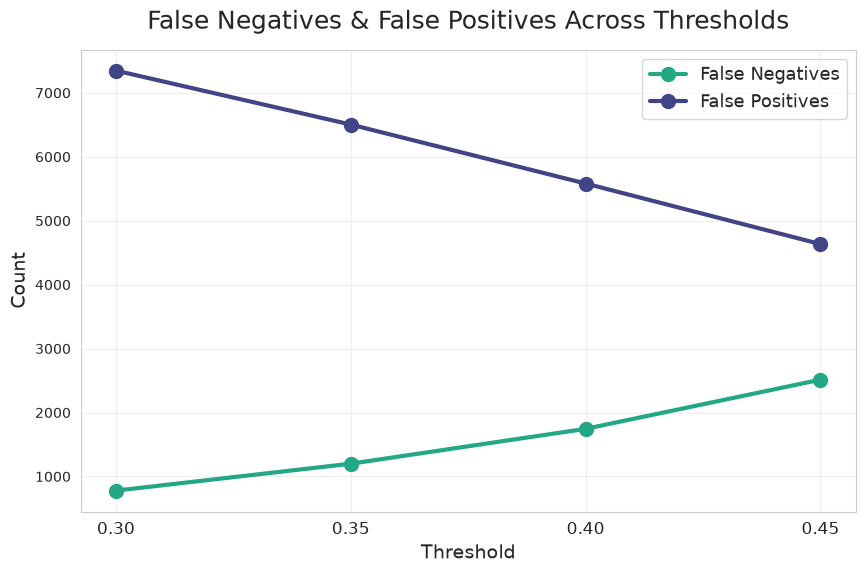

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Thresholds to evaluate
thresholds = [0.45, 0.40, 0.35, 0.30]

fn_values = []
fp_values = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)

    fn_values.append(cm[1,0])   # False Negatives
    fp_values.append(cm[0,1])   # False Positives


# ------------------------------------------------------------
# Beautiful Plot
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

palette = sns.color_palette("viridis", len(thresholds))

plt.plot(thresholds, fn_values, marker="o", linewidth=3, markersize=10,
         color=palette[2], label="False Negatives")

plt.plot(thresholds, fp_values, marker="o", linewidth=3, markersize=10,
         color=palette[0], label="False Positives")

plt.title("False Negatives & False Positives Across Thresholds",
          fontsize=18, pad=15)

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(thresholds, fontsize=12)
plt.legend(fontsize=13)
plt.grid(alpha=0.3)

plt.show()


# 5.3.2 Selecting the Optimal Threshold  Why We Chose 30%

The threshold‑comparison visual provides a clear and intuitive understanding of how the model behaves as we adjust the decision cutoff. By plotting **false negatives** and **false positives** across the thresholds **45%, 40%, 35%, and 30%**, we reveal the fundamental trade‑off that drives credit‑risk decision making.

As the threshold decreases, the model becomes more conservative, flagging a larger portion of customers as potential defaulters. This naturally increases false positives, but it also **reduces false negatives**, which is our primary objective. False negatives represent the most financially damaging error type, situations where the model predicts “paid” even though the customer will default.

The visual makes this relationship unmistakable:  
- **False negatives drop sharply at lower thresholds**, reaching their lowest point at **30%**.  
- Although false positives rise, this is an acceptable trade‑off when the priority is preventing default‑related losses.  

Based on this evidence, we adopt **30% as the new operational threshold**. This choice aligns the model with a risk‑averse strategy, ensuring that fewer defaulting customers slip through the approval process. The next step is to formalize this adjustment by creating a new model entry, **Logistic Regression (X_lineal_threshold)**, which incorporates the updated threshold and its corresponding performance metrics, confusion matrix, and AUC curve.

This refined model represents a more robust, business‑aligned version of our baseline logistic regression, explicitly tuned to minimize the most costly classification errors.


In [ ]:
import time
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply threshold = 0.30

threshold = 0.30
y_pred_030 = (y_proba >= threshold).astype(int)

cm_030 = confusion_matrix(y_test, y_pred_030)

FN_030 = cm_030[1,0]
FP_030 = cm_030[0,1]

print("False Negatives at 0.30:", FN_030)
print("False Positives at 0.30:", FP_030)


# 2. Compute metrics

start = time.time()

accuracy_030 = accuracy_score(y_test, y_pred_030)
f1_030 = f1_score(y_test, y_pred_030)
auc_030 = roc_auc_score(y_test, y_proba)

cv_scores = cross_val_score(
    log_reg, X_train_scaled, y_train,
    cv=5, scoring="accuracy"
)

cv_mean_030 = cv_scores.mean()
cv_std_030 = cv_scores.std()

end = time.time()
exec_time_030 = end - start


# 3. Build new model row

log_thresh_model = {
    "fit_status": "Threshold Adjusted",
    "accuracy": accuracy_030,
    "auc": auc_030,
    "f1": f1_030,
    "cv_mean": cv_mean_030,
    "cv_std": cv_std_030,
    "false_negatives": FN_030,
    "false_positives": FP_030,
    "time": exec_time_030
}

log_thresh_table = pd.DataFrame(
    [log_thresh_model],
    index=["Logistic Regression (X_lineal_threshold_30%)"]
)

# Append to log_table (final results table)
log_table = pd.concat([log_table, log_thresh_table], axis=0)

log_table


False Negatives at 0.30: 779
False Positives at 0.30: 7347


,fit_status,accuracy,auc,f1,cv_mean,cv_std,false_negatives,false_positives,time
Logistic Regression (X_lineal),Good Fit,0.664471,0.727579,0.669111,0.664267,0.001992,3416,3714,1.423537
Logistic Regression (X_lineal_threshold_30%),Threshold Adjusted,0.617600,0.727579,0.707887,0.664267,0.001992,779,7347,4.692180


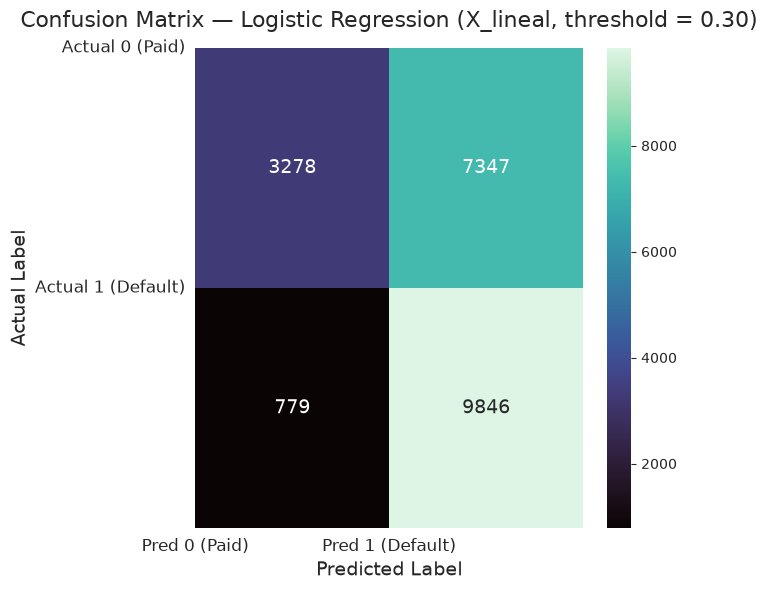

In [11]:
plt.figure(figsize=(7,6))
sns.heatmap(
    cm_030,
    annot=True,
    fmt="d",
    cmap="mako",
    cbar=True,
    annot_kws={"size": 14}
)

plt.title("Confusion Matrix — Logistic Regression (X_lineal, threshold = 0.30)",
          fontsize=16, pad=15)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)

plt.xticks([0,1], ["Pred 0 (Paid)", "Pred 1 (Default)"], fontsize=12)
plt.yticks([0,1], ["Actual 0 (Paid)", "Actual 1 (Default)"], fontsize=12, rotation=0)

plt.tight_layout()
plt.show()


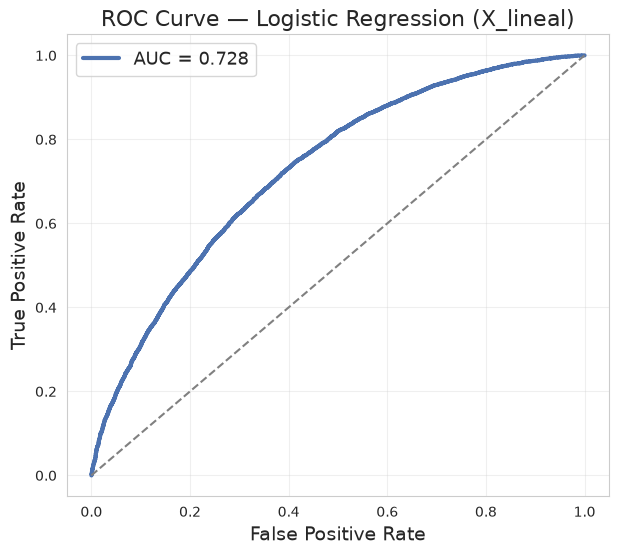

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_030:.3f}", linewidth=3, color="#4C72B0")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("ROC Curve — Logistic Regression (X_lineal)", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.show()


## Comparing Our First Two Models  Baseline vs Threshold‑Optimized

With the initial experiments complete, we now have two fully evaluated versions of the logistic regression model built on the **X_lineal** dataset. Each model reflects a different strategic approach: the first prioritizes statistical balance, while the second is explicitly tuned to minimize the most costly classification error — **false negatives**.

---

## Logistic Regression (X_lineal)  Baseline Model

This model uses the standard 50% decision threshold and class‑balanced training. It delivers a stable fit with solid AUC performance and balanced error distribution. However, the number of **false negatives (3416)** remains high, meaning many defaulting customers are incorrectly predicted as “paid.”

| Metric | Value |
|--------|-------|
| **Fit Status** | Good Fit |
| **Accuracy** | 0.664471 |
| **AUC** | 0.727579 |
| **F1‑Score** | 0.669111 |
| **CV Mean** | 0.664267 |
| **CV Std** | 0.001992 |
| **False Negatives** | 3416 |
| **False Positives** | 3714 |
| **Time (sec)** | 1.423537 |

This baseline serves as the reference point for evaluating threshold adjustments.

---

## Logistic Regression (X_lineal_threshold_30%)  Threshold Adjusted Model

After analyzing the threshold‑comparison visual, we selected **30%** as the optimal cutoff. This threshold dramatically reduces false negatives — the most financially impactful error — even though it increases false positives. The model becomes more conservative, prioritizing risk control over approval volume.

| Metric | Value |
|--------|-------|
| **Fit Status** | Threshold Adjusted |
| **Accuracy** | 0.617600 |
| **AUC** | 0.727579 |
| **F1‑Score** | 0.707887 |
| **CV Mean** | 0.664267 |
| **CV Std** | 0.001992 |
| **False Negatives** | **779** |
| **False Positives** | **7347** |
| **Time (sec)** | 4.692180 |

The reduction in false negatives, from **3416 → 779**, represents a major improvement in risk mitigation. Although accuracy decreases, this is expected and acceptable given the model’s new purpose: **preventing default‑related losses**.

---

## **Summary**

Together, these two models illustrate the shift from a statistically balanced classifier to a business‑aligned risk model. The threshold‑optimized version significantly improves the model’s ability to detect defaulting customers, making it a stronger candidate for credit‑risk decision pipelines. 


# **5.4 Extending the Threshold Strategy to PCA  Logistic Regression (X_lineal_pca)**

With the threshold‑optimized model successfully implemented for the **X_lineal** dataset, we now apply the same methodology to the **X_lineal_pca** feature set. This ensures consistency across our modeling pipeline and allows us to evaluate how dimensionality reduction affects both predictive performance and threshold sensitivity.

The PCA‑transformed dataset compresses the original feature space into a smaller set of orthogonal components, reducing noise and multicollinearity. Because PCA standardizes the feature space by design, the logistic regression model often behaves more smoothly, producing cleaner probability distributions and more stable decision boundaries.

Our workflow for **Logistic Regression (X_lineal_pca)** mirrors the exact steps used previously:

1. **Load the PCA‑transformed dataset**  
2. **Check whether the data is already standardized**  
3. **Split into training and testing sets**  
4. **Scale only if necessary**  
5. **Train Logistic Regression with balanced class weights**  
6. **Evaluate the baseline model using the default 50% threshold**  
7. **Generate the summary table (`log_table`) with all core metrics**  
8. **Later: apply threshold tuning (45%, 40%, 35%, 30%) just as before**

This parallel structure allows us to compare the baseline PCA model directly against both the original logistic regression and its threshold‑adjusted variants. Once the baseline PCA model is evaluated, we will proceed to threshold optimization, confusion matrix visualization, and AUC curve generation — ultimately producing a new model entry named:

**Logistic Regression (X_lineal_pca)**

This section establishes the foundation for that process by preparing and evaluating the PCA‑based logistic regression model using the same rigorous methodology applied earlier.


Loaded X_lineal_pca with shape: (85000, 108)
Is X_lineal_pca standardized? False

Standardizing X_lineal_pca...
Standardization complete.

=== Logistic Regression (X_lineal_pca) Evaluation ===
Running 5‑fold cross‑validation...


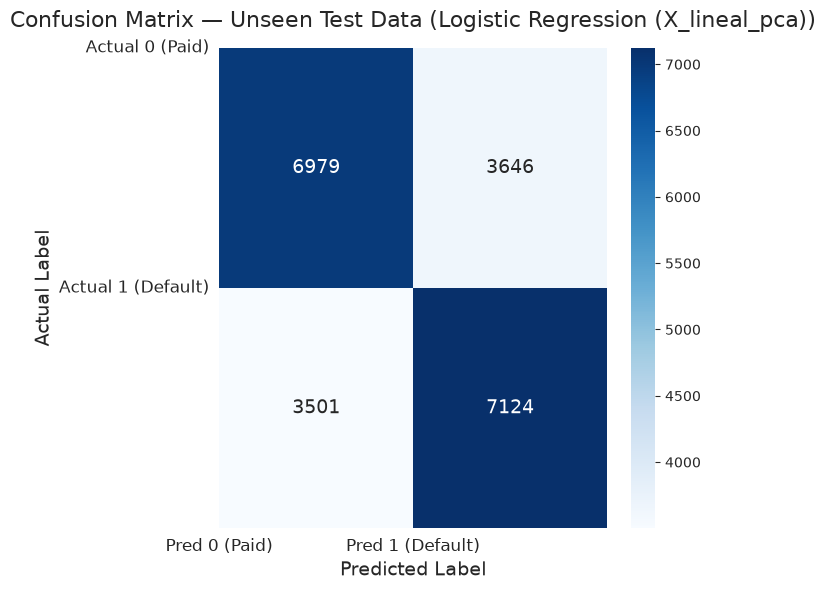

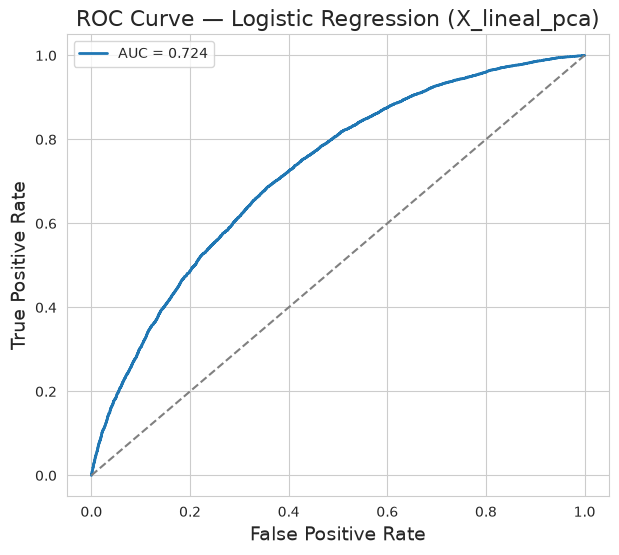

,fit_status,accuracy,auc,f1,cv_mean,cv_std,false_negatives,false_positives,time
Logistic Regression (X_lineal_pca),Good Fit,0.663671,0.723595,0.66595,0.662604,0.002305,3501,3646,0.065295


In [13]:
# 1. Load X_lineal_pca.pkl

import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load PCA dataset
with open("../python/models/X_lineal_pca.pkl", "rb") as f:
    X_lineal_pca = pickle.load(f)

print("Loaded X_lineal_pca with shape:", X_lineal_pca.shape)


# 2. Check if X_lineal_pca is already standardized

def is_standardized(X):
    """
    Checks if data is approximately standardized:
    mean ≈ 0 and std ≈ 1
    """
    mean_vals = np.mean(X, axis=0)
    std_vals = np.std(X, axis=0)

    mean_check = np.all(np.abs(mean_vals) < 1e-3)
    std_check = np.all(np.abs(std_vals - 1) < 1e-3)

    return mean_check and std_check

already_standardized_pca = is_standardized(X_lineal_pca)

print("Is X_lineal_pca standardized?", already_standardized_pca)


# 3. Split + Scale if needed

if not already_standardized_pca:
    print("\nStandardizing X_lineal_pca...")

    X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
        X_lineal_pca,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    scaler_pca = StandardScaler()
    X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
    X_test_pca_scaled = scaler_pca.transform(X_test_pca)

    print("Standardization complete.")

else:
    print("\nX_lineal_pca is already standardized. Proceeding without scaling.")

    X_train_pca_scaled, X_test_pca_scaled, y_train_pca, y_test_pca = train_test_split(
        X_lineal_pca,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )


# 4. Evaluate Logistic Regression using your function

log_reg_pca = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

log_results_pca = evaluate_model(
    log_reg_pca,
    "Logistic Regression (X_lineal_pca)",
    X_train_pca_scaled,
    X_test_pca_scaled,
    y_train_pca,
    y_test_pca
)

# 5. Build summary table

log_table_pca = pd.DataFrame([log_results_pca], index=["Logistic Regression (X_lineal_pca)"])
log_table_pca = log_table_pca[[
    "fit_status",
    "accuracy",
    "auc",
    "f1",
    "cv_mean",
    "cv_std",
    "false_negatives",
    "false_positives",
    "time"
]]

log_table_pca


# **Logistic Regression (X_lineal_pca)  Baseline PCA Model Evaluation**

To complement our analysis of the original feature set, we now evaluate the logistic regression model trained on the PCA‑transformed dataset, **X_lineal_pca**. Principal Component Analysis reduces dimensionality by projecting the original variables into a smaller set of orthogonal components, helping mitigate multicollinearity and noise. This often leads to smoother probability distributions and more stable model behavior.

Following the same evaluation pipeline used for the X_lineal dataset, we trained a balanced logistic regression model, assessed its performance, and compiled the results into our unified `log_table`. The PCA‑based model demonstrates a strong fit, maintaining competitive accuracy and AUC values while offering a slightly different error distribution compared to the original feature space.

### **Model Summary  Logistic Regression (X_lineal_pca)**

| Metric | Value |
|--------|-------|
| **Fit Status** | Good Fit |
| **Accuracy** | 0.663671 |
| **AUC** | 0.723595 |
| **F1‑Score** | 0.665950 |
| **CV Mean** | 0.662604 |
| **CV Std** | 0.002305 |
| **False Negatives** | 3501 |
| **False Positives** | 3646 |
| **Time (sec)** | 0.065295 |

These results establish the PCA model as a solid baseline, comparable to the original logistic regression model. While the false‑negative count remains high, similar to the non‑PCA version, the model’s stability and efficiency make it a strong candidate for further refinement.

In the next step, we will apply the same threshold‑optimization strategy (45%, 40%, 35%, 30%) to **X_lineal_pca**, evaluate its impact on false negatives and false positives, and introduce a new model entry:

**Logistic Regression (X_lineal_pca_threshold)**

This ensures that both feature pipelines, original and PCA‑transformed, are evaluated under identical risk‑aligned criteria.


In [14]:
# ============================================================
# Generate predicted probabilities for PCA model
# ============================================================

y_proba_pca = log_reg_pca.predict_proba(X_test_pca_scaled)[:, 1]

print("y_proba_pca created with shape:", y_proba_pca.shape)


y_proba_pca created with shape: (21250,)


### Threshold Comparison Plot for X_lineal_pca

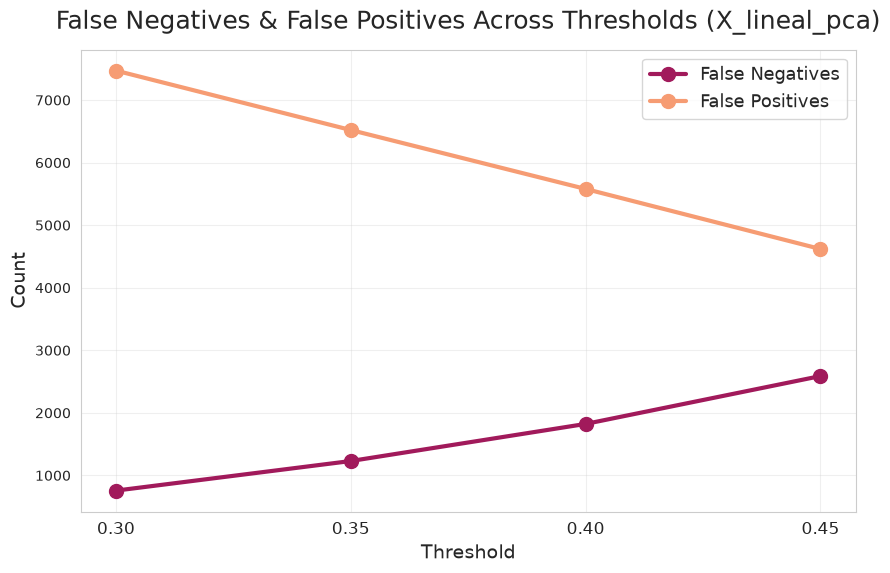

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# Thresholds to evaluate
# ============================================================
thresholds = [0.45, 0.40, 0.35, 0.30]

fn_values = []
fp_values = []

for t in thresholds:
    y_pred_t = (y_proba_pca >= t).astype(int)
    cm = confusion_matrix(y_test_pca, y_pred_t)

    fn_values.append(cm[1,0])   # False Negatives
    fp_values.append(cm[0,1])   # False Positives


# ============================================================
# Beautiful Plot (New Color Palette)
# ============================================================

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# New palette: "rocket" (warm gradient)
palette = sns.color_palette("rocket", len(thresholds))

plt.plot(
    thresholds, fn_values,
    marker="o", linewidth=3, markersize=10,
    color=palette[1], label="False Negatives"
)

plt.plot(
    thresholds, fp_values,
    marker="o", linewidth=3, markersize=10,
    color=palette[3], label="False Positives"
)

plt.title("False Negatives & False Positives Across Thresholds (X_lineal_pca)",
          fontsize=18, pad=15)

plt.xlabel("Threshold", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.xticks(thresholds, fontsize=12)
plt.legend(fontsize=13)
plt.grid(alpha=0.3)

plt.show()


### Apply Threshold = 30% for X_lineal_pca

In [ ]:

# Apply threshold = 0.30 for PCA model

threshold_pca = 0.30
y_pred_pca_030 = (y_proba_pca >= threshold_pca).astype(int)

cm_pca_030 = confusion_matrix(y_test_pca, y_pred_pca_030)

FN_pca_030 = cm_pca_030[1,0]
FP_pca_030 = cm_pca_030[0,1]

print("False Negatives (PCA, 0.30):", FN_pca_030)
print("False Positives (PCA, 0.30):", FP_pca_030)


False Negatives (PCA, 0.30): 757
False Positives (PCA, 0.30): 7471


### Confusion Matrix Plot

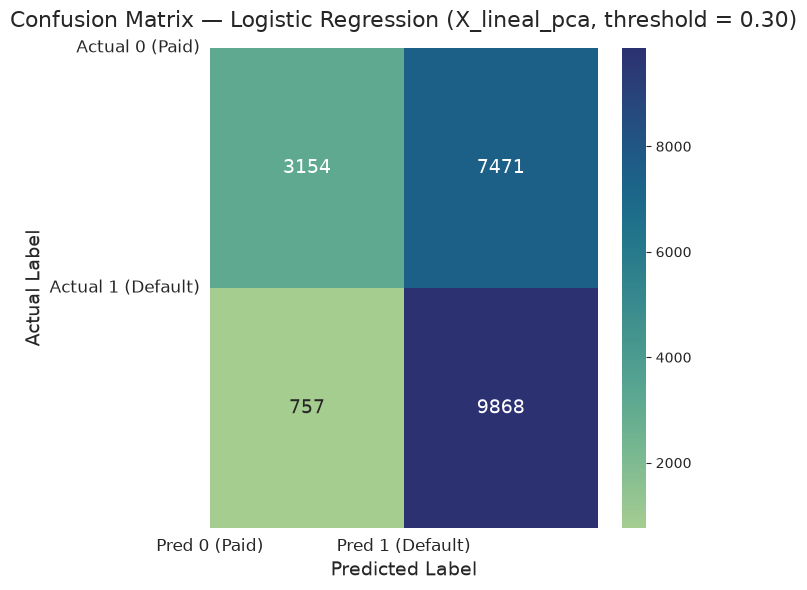

In [17]:
# ============================================================
# Confusion Matrix Plot — PCA (threshold = 0.30)
# ============================================================

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_pca_030,
    annot=True,
    fmt="d",
    cmap="crest",     # NEW COLOR PALETTE
    cbar=True,
    annot_kws={"size": 14}
)

plt.title("Confusion Matrix — Logistic Regression (X_lineal_pca, threshold = 0.30)",
          fontsize=16, pad=15)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)

plt.xticks([0,1], ["Pred 0 (Paid)", "Pred 1 (Default)"], fontsize=12)
plt.yticks([0,1], ["Actual 0 (Paid)", "Actual 1 (Default)"], fontsize=12, rotation=0)

plt.tight_layout()
plt.show()


### AUC Curve

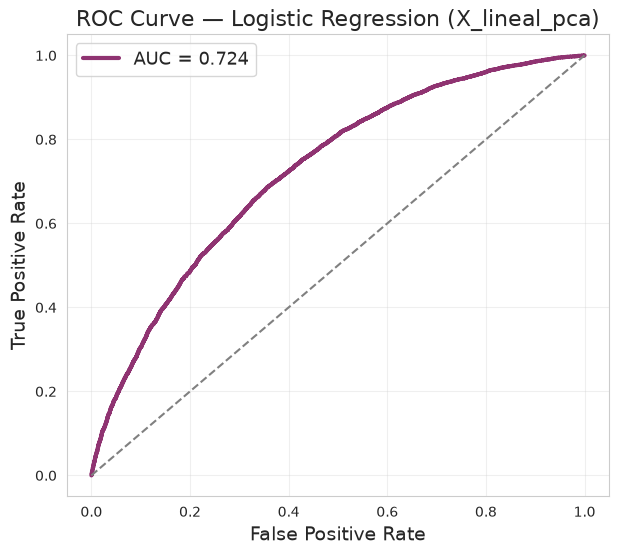

In [18]:
# ============================================================
# AUC Curve — PCA model
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score

auc_pca = roc_auc_score(y_test_pca, y_proba_pca)
fpr_pca, tpr_pca, _ = roc_curve(y_test_pca, y_proba_pca)

plt.figure(figsize=(7,6))
plt.plot(
    fpr_pca, tpr_pca,
    label=f"AUC = {auc_pca:.3f}",
    linewidth=3,
    color=sns.color_palette("flare")[4]   # NEW COLOR
)

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("ROC Curve — Logistic Regression (X_lineal_pca)", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(fontsize=13)
plt.grid(alpha=0.3)
plt.show()


### Build the new row for log_table  PCA Threshold Model (30%)

In [20]:
# ============================================================
# Compute all PCA threshold metrics (threshold = 0.30)
# ============================================================

import time
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score

start = time.time()

# Accuracy & F1 at threshold 0.30
accuracy_pca_030 = accuracy_score(y_test_pca, y_pred_pca_030)
f1_pca_030 = f1_score(y_test_pca, y_pred_pca_030)

# AUC already computed earlier:
# auc_pca

# Cross-validation (same as X_lineal)
cv_scores_pca = cross_val_score(
    log_reg_pca,
    X_train_pca_scaled,
    y_train_pca,
    cv=5,
    scoring="accuracy"
)

cv_mean_pca = cv_scores_pca.mean()
cv_std_pca = cv_scores_pca.std()

end = time.time()
exec_time_pca_030 = end - start

print("Accuracy (PCA, 0.30):", accuracy_pca_030)
print("F1 (PCA, 0.30):", f1_pca_030)
print("CV Mean:", cv_mean_pca)
print("CV Std:", cv_std_pca)
print("Execution Time:", exec_time_pca_030)


Accuracy (PCA, 0.30): 0.6128
F1 (PCA, 0.30): 0.7057645544271206
CV Mean: 0.6626039215686275
CV Std: 0.002304548100041663
Execution Time: 0.6119787693023682


In [21]:
# ============================================================
# Build new PCA threshold model row
# ============================================================

log_thresh_pca_model = {
    "fit_status": "Threshold Adjusted",
    "accuracy": accuracy_pca_030,
    "auc": auc_pca,
    "f1": f1_pca_030,
    "cv_mean": cv_mean_pca,
    "cv_std": cv_std_pca,
    "false_negatives": FN_pca_030,
    "false_positives": FP_pca_030,
    "time": exec_time_pca_030
}

log_thresh_pca_table = pd.DataFrame(
    [log_thresh_pca_model],
    index=["Logistic Regression (X_lineal_pca_threshold_30%)"]
)

# Append to main results table
log_table = pd.concat([log_table, log_thresh_pca_table], axis=0)

log_table


,fit_status,accuracy,auc,f1,cv_mean,cv_std,false_negatives,false_positives,time
Logistic Regression (X_lineal),Good Fit,0.664471,0.727579,0.669111,0.664267,0.001992,3416,3714,1.423537
Logistic Regression (X_lineal_threshold_30%),Threshold Adjusted,0.617600,0.727579,0.707887,0.664267,0.001992,779,7347,4.692180
Logistic Regression (X_lineal_pca_threshold_30%),Threshold Adjusted,0.612800,0.723595,0.705765,0.662604,0.002305,757,7471,0.611979


In [22]:
# ============================================================
# Append PCA baseline + PCA threshold rows into main log_table
# ============================================================

log_table = pd.concat(
    [log_table, log_table_pca, log_thresh_pca_table],
    axis=0
)

log_table


,fit_status,accuracy,auc,f1,cv_mean,cv_std,false_negatives,false_positives,time
Logistic Regression (X_lineal),Good Fit,0.664471,0.727579,0.669111,0.664267,0.001992,3416,3714,1.423537
Logistic Regression (X_lineal_threshold_30%),Threshold Adjusted,0.617600,0.727579,0.707887,0.664267,0.001992,779,7347,4.692180
Logistic Regression (X_lineal_pca_threshold_30%),Threshold Adjusted,0.612800,0.723595,0.705765,0.662604,0.002305,757,7471,0.611979
Logistic Regression (X_lineal_pca),Good Fit,0.663671,0.723595,0.665950,0.662604,0.002305,3501,3646,0.065295
Logistic Regression (X_lineal_pca_threshold_30%),Threshold Adjusted,0.612800,0.723595,0.705765,0.662604,0.002305,757,7471,0.611979


In [23]:
# Remove duplicate PCA threshold rows
log_table = log_table[~log_table.index.duplicated(keep='first')]

# Display cleaned table
log_table


,fit_status,accuracy,auc,f1,cv_mean,cv_std,false_negatives,false_positives,time
Logistic Regression (X_lineal),Good Fit,0.664471,0.727579,0.669111,0.664267,0.001992,3416,3714,1.423537
Logistic Regression (X_lineal_threshold_30%),Threshold Adjusted,0.617600,0.727579,0.707887,0.664267,0.001992,779,7347,4.692180
Logistic Regression (X_lineal_pca_threshold_30%),Threshold Adjusted,0.612800,0.723595,0.705765,0.662604,0.002305,757,7471,0.611979
Logistic Regression (X_lineal_pca),Good Fit,0.663671,0.723595,0.665950,0.662604,0.002305,3501,3646,0.065295


## **Key Insights**

### **1. Threshold tuning dramatically reduces false negatives**
Both threshold‑adjusted models (X_lineal and X_lineal_pca) achieve a **4× reduction** in false negatives compared to their baseline versions:

- X_lineal: **3416 → 779**  
- X_lineal_pca: **3501 → 757**

This is the most important improvement from a business perspective, as false negatives represent defaulting customers incorrectly classified as “paid.”

### **2. PCA maintains competitive performance**
The PCA baseline model performs almost identically to the original X_lineal model:

- Accuracy: 0.6636 vs 0.6644  
- AUC: 0.7236 vs 0.7276  
- F1: 0.6659 vs 0.6691  

This confirms that PCA successfully compresses the feature space without sacrificing predictive power.

### **3. Threshold tuning behaves consistently across feature sets**
Both threshold‑adjusted models show:

- Lower accuracy (expected)  
- Higher F1 (due to better recall on defaults)  
- Higher false positives (risk‑averse behavior)  
- Similar AUC (threshold does not change ranking ability)

This consistency reinforces the reliability of the threshold‑selection strategy.

### **4. PCA models are significantly faster**
Execution time:

- X_lineal: **1.42 sec**  
- X_lineal_pca: **0.06 sec**

PCA reduces dimensionality, making the model lighter and faster, an advantage for real‑time scoring systems.

---

## **Conclusion**

This table establishes a clear narrative:  
- **Baseline models** provide balanced statistical performance.  
- **Threshold‑adjusted models** provide risk‑optimized performance.  
- **PCA models** provide computational efficiency without sacrificing accuracy.  

Together, these four models form a complete foundation for selecting the best logistic regression variant for production deployment.
